In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
from graphviz import Digraph
%matplotlib inline

In [6]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{%s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [26]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0 # initially, this node doesn't affect the final value (therefore 0 gradient)
        self._backward = lambda: None # by default, nothing to do (for leaf node)
        
        self._prev = set(_children) # who is contributing to this value?
        self._op = _op # what operation created this value?
        self.label = label # label to represent in like visualizing graphs

    def __repr__(self): # python uses __repr__ internally to return a string or something as a representation
        # instead of just showing location in memory
        return f"Value(data={self.data})"

    def __add__(self, other): # special method to define the plus operator for this object:
        # a + b will be a.__add__(b), and b will be passed as other
        out = Value(self.data + other.data, (self, other), '+') # making self and other as prev of this value

        def _backward():
            self.grad = 1.0 * out.grad # local derivative * global der of out
            other.grad = 1.0 * out.grad # same logic

        out._backward = _backward # assigning it this function
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad = other.data * out.grad # local * global of out
            other.grad = self.data * out.grad

        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), "tanh")

        def _backward():
            # we already have
            self.grad = (1-t**2) * out.grad # local * global of out
        
        out._backward = _backward
        return out

In [51]:
# This gets a comback, now not having to do manual calcs:

# neurons themselves:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights of connections:
w1 = Value(-3, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron:
b = Value(6.8813735870195432, label='b')
# following the above human neuron model and creating an input for the
# tanh function:
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
weighted_sum = x1w1 + x2w2; weighted_sum.label = 'x1w1 + x2w2'
n = weighted_sum + b; n.label = 'n'

o = n.tanh(); o.label='o' # involves exponentiation, so needs custom method

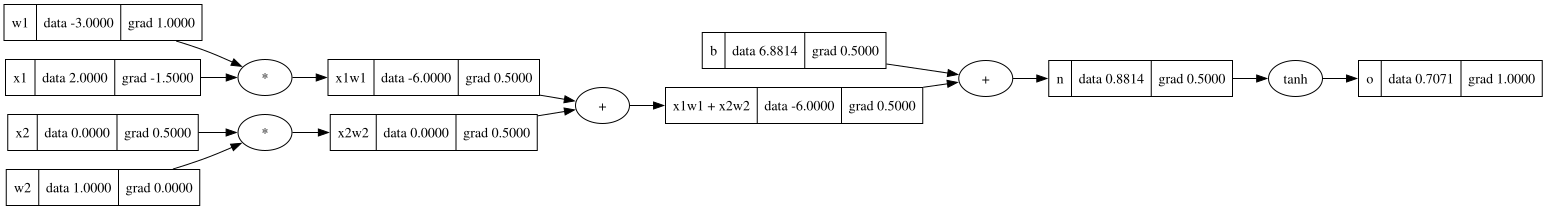

In [40]:
o.grad = 1.0 # must initialize the last node
o._backward()
n._backward()
b._backward()
weighted_sum._backward()
x1w1._backward()
x2w2._backward()
x1._backward()
w1._backward()
x2._backward()
w2._backward()

draw_dot(o)

In [41]:
# Now, let's figure out a way so that we don't have to 
# Manually call _backward() ourselves to backpropagate

# The principle behind is, to backpropagate a node, we have
# to wait until all the operations and backpropagating of 
# nodes ahead of it are done (it's dependencies)

# This ordering of nodes can be achieved by using a topological sort
# (laying out of nodes such that all the edges only go one way, i.e.
# left to right)

In [42]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo        

[Value(data=2.0),
 Value(data=-3),
 Value(data=-6.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

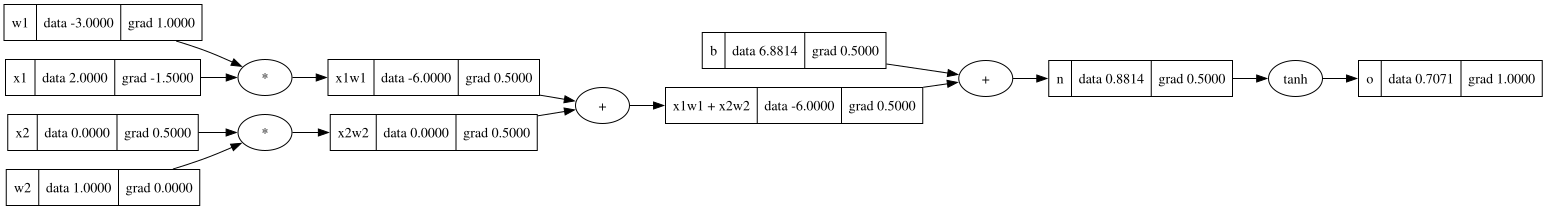

In [44]:
# now that we have a topological sort, we just set
# the gradient of the last item to 1, and iterate through
# the remaining from right to left in the array,
# calling their ._backward()

o.grad = 1.0
for i in range(len(topo) - 1, -1, -1):
    topo[i]._backward()

draw_dot(o)

In [50]:
# Finally, we can hide this entire functionality of backpropagation
# inside of the Value class:

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0 # initially, this node doesn't affect the final value (therefore 0 gradient)
        self._backward = lambda: None # by default, nothing to do (for leaf node)
        
        self._prev = set(_children) # who is contributing to this value?
        self._op = _op # what operation created this value?
        self.label = label # label to represent in like visualizing graphs

    def __repr__(self): # python uses __repr__ internally to return a string or something as a representation
        # instead of just showing location in memory
        return f"Value(data={self.data})"

    def __add__(self, other): # special method to define the plus operator for this object:
        # a + b will be a.__add__(b), and b will be passed as other
        out = Value(self.data + other.data, (self, other), '+') # making self and other as prev of this value

        def _backward():
            self.grad = 1.0 * out.grad # local derivative * global der of out
            other.grad = 1.0 * out.grad # same logic

        out._backward = _backward # assigning it this function
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad = other.data * out.grad # local * global of out
            other.grad = self.data * out.grad

        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), "tanh")

        def _backward():
            # we already have
            self.grad = (1-t**2) * out.grad # local * global of out
        
        out._backward = _backward
        return out
        
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self) # builds it from here and back

        self.grad = 1.0 # assuming this is the last thing
        for node in reversed(topo):
            node._backward()
        

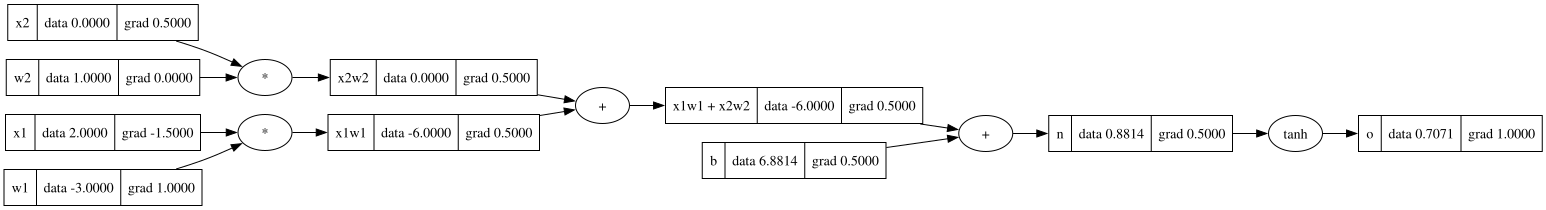

In [52]:
o.backward()
draw_dot(o)

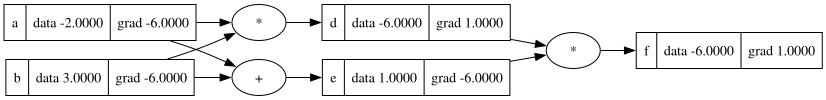

In [59]:
# Note, there is a bug right now in the above Value class
# where if you use the same object twice in like an addition or
# multiplication, the gradients are wrong

# this is because the same object is passed as both self and other
# and once it's being written to, it's being overrided since both
# objects are the same

# and also can happen if the same variables are references again (overwritten again)
# Example case 1: 
a = Value(3.0, label='a') # a.grad should end up 2, which it is not
b = a + a; b.label='b' 
b.backward()
draw_dot(b)

# Example case 2:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a*b; d.label = 'd'
e = a+b; e.label = 'e'
f = d*e; f.label = 'f'
f.backward()
draw_dot(f)

In [61]:
# Simple solution: accumulate gradient instead:
# whenever previously assigning a gradient, use += there instead
# (visualize this fix by 1+1 gradient of a+a)

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0 # initially, this node doesn't affect the final value (therefore 0 gradient)
        self._backward = lambda: None # by default, nothing to do (for leaf node)
        
        self._prev = set(_children) # who is contributing to this value?
        self._op = _op # what operation created this value?
        self.label = label # label to represent in like visualizing graphs

    def __repr__(self): # python uses __repr__ internally to return a string or something as a representation
        # instead of just showing location in memory
        return f"Value(data={self.data})"

    def __add__(self, other): # special method to define the plus operator for this object:
        # a + b will be a.__add__(b), and b will be passed as other
        out = Value(self.data + other.data, (self, other), '+') # making self and other as prev of this value

        def _backward():
            self.grad += 1.0 * out.grad # local derivative * global der of out
            other.grad += 1.0 * out.grad # same logic

        out._backward = _backward # assigning it this function
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad # local * global of out
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), "tanh")

        def _backward():
            # we already have
            self.grad += (1-t**2) * out.grad # local * global of out
        
        out._backward = _backward
        return out
        
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self) # builds it from here and back

        self.grad = 1.0 # assuming this is the last thing
        for node in reversed(topo):
            node._backward()
        

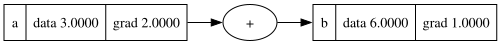

In [63]:
# Example case 1: 
a = Value(3.0, label='a') # a.grad should end up 2, which it is not
b = a + a; b.label='b' 
b.backward()
draw_dot(b) # NOW WORKS